In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "utils.py").exists() and (ROOT.parent / "src" / "utils.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils import DATA_CLEANED, load_jsonl
pd.set_option("display.max_colwidth", None)
sns.set_theme(style="whitegrid")

In [2]:
TICKERS = ["NVDA", "MSFT", "AAPL", "AMZN", "GOOGL", "META", "TSLA"]
SENTIMENT_COLS = [
    "sentiment_finbert",
    "sentiment_llm_phi3",
    "sentiment_llm_llama3_2",
    "sentiment_llm_deepseek_r1",
]

In [3]:
path = DATA_CLEANED / "processed_base_data.jsonl"
rows = load_jsonl(path)
df = pd.DataFrame(rows)

In [4]:
df.dtypes

posted_at                        str
fetched_at                       str
headline                         str
url                              str
source                           str
reporter                         str
ticker                           str
is_ai_related                    str
is_proxy_partnership             str
sentiment_finbert            float64
sentiment_llm_phi3           float64
sentiment_llm_llama3_2       float64
sentiment_llm_deepseek_r1    float64
dtype: object

In [5]:
df.head()

,posted_at,fetched_at,headline,url,source,reporter,ticker,is_ai_related,is_proxy_partnership,sentiment_finbert,sentiment_llm_phi3,sentiment_llm_llama3_2,sentiment_llm_deepseek_r1
0,2026-02-23T21:47:00Z,2026-02-26T15:43:31Z,AirPods as Apple’s first AI wearable product makes so much sense - 9to5Mac,https://9to5mac.com/2026/02/23/airpods-as-apples-first-ai-wearable-product-makes-so-much-sense/,NewsAPI Tech,9to5Mac,AAPL,True,False,0.186437,0.6,0.4,0.9
1,2026-02-24T05:45:00Z,2026-02-26T15:43:31Z,Gemini 3.1 Pro is a powerhouse for deep work — here are 7 prompts that prove it - Tom's Guide,https://www.tomsguide.com/ai/gemini-3-1-pro-is-a-powerhouse-for-deep-work-here-are-7-prompts-that-prove-it,NewsAPI Tech,Tom's Guide,GOOGL,True,False,0.048727,0.6,0.4,-0.5
2,2026-02-24T16:57:21Z,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,AAPL,True,True,0.001451,0.6,0.3,0.5
3,2026-02-24T16:57:21Z,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,GOOGL,True,False,0.001451,0.6,0.3,0.5
4,2026-02-24T17:30:10Z,2026-02-26T15:43:31Z,Microsoft adds Copilot data controls to all storage locations - BleepingComputer,https://www.bleepingcomputer.com/news/microsoft/microsoft-adds-copilot-data-controls-to-all-storage-locations/,NewsAPI Tech,BleepingComputer,MSFT,True,False,0.089283,-0.2,-0.8,0.0


In [6]:
df_ts = df.copy()
df_ts["posted_at"] = pd.to_datetime(df_ts["posted_at"], utc=True, errors="coerce")
df_ts["date"] = df_ts["posted_at"].dt.tz_convert(None).dt.normalize()
df_ts.head()

,posted_at,fetched_at,headline,url,source,reporter,ticker,is_ai_related,is_proxy_partnership,sentiment_finbert,sentiment_llm_phi3,sentiment_llm_llama3_2,sentiment_llm_deepseek_r1,date
0,2026-02-23 21:47:00+00:00,2026-02-26T15:43:31Z,AirPods as Apple’s first AI wearable product makes so much sense - 9to5Mac,https://9to5mac.com/2026/02/23/airpods-as-apples-first-ai-wearable-product-makes-so-much-sense/,NewsAPI Tech,9to5Mac,AAPL,True,False,0.186437,0.6,0.4,0.9,2026-02-23
1,2026-02-24 05:45:00+00:00,2026-02-26T15:43:31Z,Gemini 3.1 Pro is a powerhouse for deep work — here are 7 prompts that prove it - Tom's Guide,https://www.tomsguide.com/ai/gemini-3-1-pro-is-a-powerhouse-for-deep-work-here-are-7-prompts-that-prove-it,NewsAPI Tech,Tom's Guide,GOOGL,True,False,0.048727,0.6,0.4,-0.5,2026-02-24
2,2026-02-24 16:57:21+00:00,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,AAPL,True,True,0.001451,0.6,0.3,0.5,2026-02-24
3,2026-02-24 16:57:21+00:00,2026-02-26T15:43:31Z,Music generator ProducerAI joins Google Labs - TechCrunch,https://techcrunch.com/2026/02/24/music-generator-producerai-joins-google-labs/,NewsAPI Tech,TechCrunch,GOOGL,True,False,0.001451,0.6,0.3,0.5,2026-02-24
4,2026-02-24 17:30:10+00:00,2026-02-26T15:43:31Z,Microsoft adds Copilot data controls to all storage locations - BleepingComputer,https://www.bleepingcomputer.com/news/microsoft/microsoft-adds-copilot-data-controls-to-all-storage-locations/,NewsAPI Tech,BleepingComputer,MSFT,True,False,0.089283,-0.2,-0.8,0.0,2026-02-24


In [7]:
daily = (
    df_ts.groupby(["ticker", "date"], as_index=False)
         .agg(
             headline_count=("headline", "count"),
             finbert_avg=("sentiment_finbert", "mean"),
             phi3_avg=("sentiment_llm_phi3", "mean"),
             llama3_avg=("sentiment_llm_llama3_2", "mean"),
             deepseek_avg=("sentiment_llm_deepseek_r1", "mean"),
         )
         .sort_values(["ticker", "date"])
)
avg_cols = ["finbert_avg", "phi3_avg", "llama3_avg", "deepseek_avg"]

daily = daily.sort_values(["ticker", "date"])
daily[avg_cols] = daily.groupby("ticker")[avg_cols].ffill()

daily['phi_delta'] = daily['phi3_avg'] - daily['finbert_avg']
daily['llama_delta'] = daily['llama3_avg'] - daily['finbert_avg']
daily['deepseek_delta'] = daily['deepseek_avg'] - daily['finbert_avg']
daily['delta_sum'] = abs(daily['phi_delta']) + abs(daily['llama_delta']) + abs(daily['deepseek_delta'])
daily["delta_mean_signed"] = (
    daily["phi_delta"] + daily["llama_delta"] + daily["deepseek_delta"]
) / 3
# cross-LLM disagreement spread
daily["llm_spread"] = daily[["phi3_avg", "llama3_avg", "deepseek_avg"]].std(axis=1)
daily.head()



,ticker,date,headline_count,finbert_avg,phi3_avg,llama3_avg,deepseek_avg,phi_delta,llama_delta,deepseek_delta,delta_sum,delta_mean_signed,llm_spread
0,AAPL,2026-02-23,1,0.186437,0.600000,0.400000,0.900000,0.413563,0.213563,0.713563,1.340690,0.446897,0.251661
1,AAPL,2026-02-24,3,-0.268251,0.066667,-0.100000,0.666667,0.334917,0.168251,0.934917,1.438086,0.479362,0.403228
2,AAPL,2026-02-25,4,-0.380745,-0.200000,-0.125000,-0.225000,0.180745,0.255745,0.155745,0.592234,0.197411,0.052042
3,AAPL,2026-02-26,5,0.096930,0.680000,0.460000,0.120000,0.583070,0.363070,0.023070,0.969209,0.323070,0.282135
4,AAPL,2026-02-27,12,-0.203112,-0.079167,-0.258333,-0.250000,0.123945,-0.055221,-0.046888,0.226055,0.007279,0.101122


In [8]:
daily.isna().sum()

ticker               0
date                 0
headline_count       0
finbert_avg          0
phi3_avg             0
llama3_avg           0
deepseek_avg         0
phi_delta            0
llama_delta          0
deepseek_delta       0
delta_sum            0
delta_mean_signed    0
llm_spread           0
dtype: int64

## Stock Prices

In [9]:
HORIZONS = [1, 3, 5, 7]

events = daily.copy()
events["date"] = pd.to_datetime(events["date"], utc=True, errors="coerce")
events = events.dropna(subset=["date", "ticker"]).copy()
events["event_date"] = events["date"].dt.tz_convert(None).dt.normalize()

tickers = sorted(df["ticker"].dropna().unique().tolist())

start = (events["date"].min().date() - pd.Timedelta(days=5))
end = (events["date"].max().date() + pd.Timedelta(days=5))

In [10]:
raw_px = yf.download(
    tickers=tickers,
    start=str(start),
    end=str(end),
    interval="1d",
    auto_adjust=False,
    group_by="ticker",
    progress=False,
)

In [11]:
px_frames = []
for t in tickers:
    p = raw_px[t].reset_index().copy()
    p.columns = [c if isinstance(c, str) else c[0] for c in p.columns]
    p = p[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]].copy()
    p.rename(columns={"Date": "trade_date"}, inplace=True)
    p["trade_date"] = pd.to_datetime(p["trade_date"]).dt.normalize()
    p["ticker"] = t

    p = p.sort_values("trade_date").reset_index(drop=True)
    p["ret_eod"] = p["Close"] / p["Close"].shift(1) - 1
    for h in HORIZONS:
        p[f"ret_{h}d"] = p["Close"].shift(-h) / p["Close"] - 1
    px_frames.append(p)

prices = pd.concat(px_frames, ignore_index=True)
price = prices[["ticker", "trade_date", "Open", "Close", "ret_eod", "ret_1d", "ret_3d", "ret_5d", "ret_7d"]].copy()
price.head()

,ticker,trade_date,Open,Close,ret_eod,ret_1d,ret_3d,ret_5d,ret_7d
0,AAPL,2026-02-18,263.600006,264.350006,NaN,-0.014261,0.006923,0.037375,-0.000643
1,AAPL,2026-02-19,262.600006,260.579987,-0.014261,0.015350,0.044363,0.047471,0.015888
2,AAPL,2026-02-20,258.970001,264.579987,0.015350,0.006047,0.036473,-0.001512,-0.003137
3,AAPL,2026-02-23,263.489990,266.179993,0.006047,0.022391,0.025434,-0.005485,-0.013750
4,AAPL,2026-02-24,267.859985,272.140015,0.022391,0.007680,-0.029250,-0.030830,-0.043544


In [12]:
events["event_date"] = events["event_date"].astype("datetime64[us]")
prices["trade_date"] = prices["trade_date"].astype("datetime64[us]")

left = events.sort_values("event_date").reset_index(drop=True).copy()
right = prices.sort_values("trade_date").reset_index(drop=True).copy()

aligned = pd.merge_asof(
    left,
    right,
    by="ticker",
    left_on="event_date",
    right_on="trade_date",
    direction="forward",
)

In [13]:
aligned.dtypes

ticker                               str
date                 datetime64[us, UTC]
headline_count                     int64
finbert_avg                      float64
phi3_avg                         float64
llama3_avg                       float64
deepseek_avg                     float64
phi_delta                        float64
llama_delta                      float64
deepseek_delta                   float64
delta_sum                        float64
delta_mean_signed                float64
llm_spread                       float64
event_date                datetime64[us]
trade_date                datetime64[us]
Open                             float64
High                             float64
Low                              float64
Close                            float64
Adj Close                        float64
Volume                             int64
ret_eod                          float64
ret_1d                           float64
ret_3d                           float64
ret_5d          

In [14]:
final_df = aligned[['ticker','event_date','ret_eod','ret_1d','ret_3d','ret_5d','ret_7d','finbert_avg','phi3_avg','llama3_avg','deepseek_avg','delta_mean_signed','llm_spread']].copy()
final_df.head()

,ticker,event_date,ret_eod,ret_1d,ret_3d,ret_5d,ret_7d,finbert_avg,phi3_avg,llama3_avg,deepseek_avg,delta_mean_signed,llm_spread
0,AAPL,2026-02-23,0.006047,0.022391,0.025434,-0.005485,-0.013750,0.186437,0.600000,0.400000,0.900000,0.446897,0.251661
1,AAPL,2026-02-24,0.022391,0.007680,-0.029250,-0.030830,-0.043544,-0.268251,0.066667,-0.100000,0.666667,0.479362,0.403228
2,MSFT,2026-02-24,0.011782,0.029820,0.009614,0.038380,0.055733,-0.046249,0.100000,-0.150000,0.600000,0.229583,0.381881
3,GOOGL,2026-02-24,-0.001894,0.006433,0.002766,-0.023545,-0.032229,0.025089,0.600000,0.350000,0.000000,0.291578,0.301386
4,NVDA,2026-02-24,0.006787,0.014052,-0.081203,-0.066373,-0.049313,-0.091427,0.200000,0.066667,0.800000,0.446982,0.390631


In [15]:
aligned.head()

,ticker,date,headline_count,finbert_avg,phi3_avg,llama3_avg,deepseek_avg,phi_delta,llama_delta,deepseek_delta,...,High,Low,Close,Adj Close,Volume,ret_eod,ret_1d,ret_3d,ret_5d,ret_7d
0,AAPL,2026-02-23 00:00:00+00:00,1,0.186437,0.600000,0.400000,0.900000,0.413563,0.213563,0.713563,...,269.429993,263.380005,266.179993,266.179993,37308200,0.006047,0.022391,0.025434,-0.005485,-0.013750
1,AAPL,2026-02-24 00:00:00+00:00,3,-0.268251,0.066667,-0.100000,0.666667,0.334917,0.168251,0.934917,...,274.890015,267.709991,272.140015,272.140015,47014600,0.022391,0.007680,-0.029250,-0.030830,-0.043544
2,MSFT,2026-02-24 00:00:00+00:00,4,-0.046249,0.100000,-0.150000,0.600000,0.146249,-0.103751,0.646249,...,389.359985,381.709991,389.000000,389.000000,33884700,0.011782,0.029820,0.009614,0.038380,0.055733
3,GOOGL,2026-02-24 00:00:00+00:00,2,0.025089,0.600000,0.350000,0.000000,0.574911,0.324911,-0.025089,...,312.269989,305.929993,310.899994,310.681305,25615600,-0.001894,0.006433,0.002766,-0.023545,-0.032229
4,NVDA,2026-02-24 00:00:00+00:00,3,-0.091427,0.200000,0.066667,0.800000,0.291427,0.158093,0.891427,...,193.770004,187.399994,192.850006,192.839569,175123600,0.006787,0.014052,-0.081203,-0.066373,-0.049313


# Sentiment-Return Correlations (Daily-Average)

In [17]:
sentiment_cols = [
    "finbert_avg",
    "phi3_avg",
    "llama3_avg",
    "deepseek_avg",
]
horizon_cols = ["ret_eod", "ret_1d", "ret_3d", "ret_5d", "ret_7d"]
cols = sentiment_cols + horizon_cols

<Axes: >

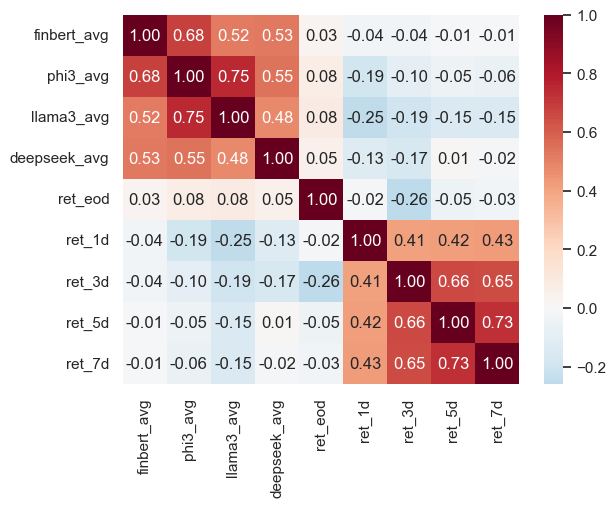

In [18]:
sns.heatmap(aligned[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)

High correlation between models but low correlation with returns --> models agree but don't predict price

## By Ticker

In [19]:
def plot_sentiment_corr(aligned, sentiment_col, title, tickers=TICKERS, horizon_cols=horizon_cols):
    corr_rows = {}
    for t in tickers:
        sub = aligned[aligned["ticker"] == t]
        corr_rows[t] = sub[[sentiment_col] + horizon_cols].corr()[sentiment_col][horizon_cols]

    corr_table = pd.DataFrame(corr_rows).T
    corr_table.columns = ["EOD", "1D", "3D", "5D", "7D"]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        corr_table,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0,
        vmin=-0.3,
        vmax=0.3,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Return Horizon")
    ax.set_ylabel("Ticker")
    plt.tight_layout()
    plt.show()

### FinBERT

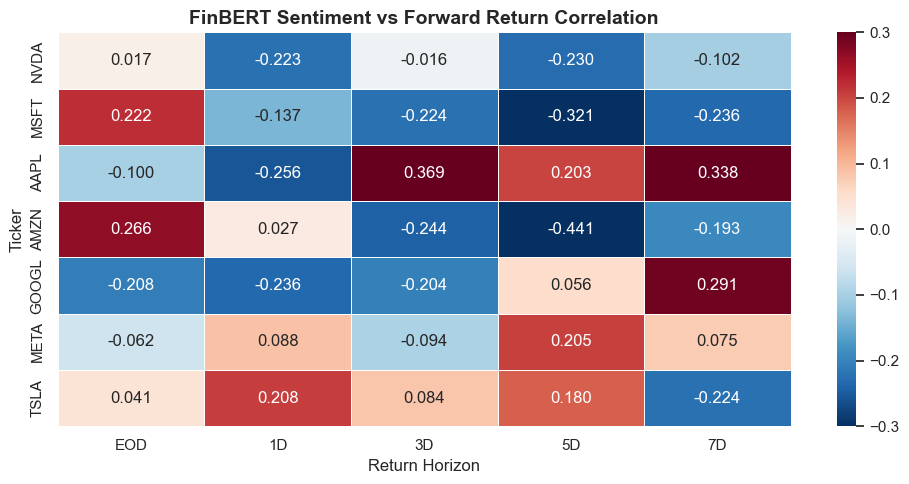

In [20]:
plot_sentiment_corr(aligned, sentiment_cols[0], "FinBERT Sentiment vs Forward Return Correlation")

### phi3

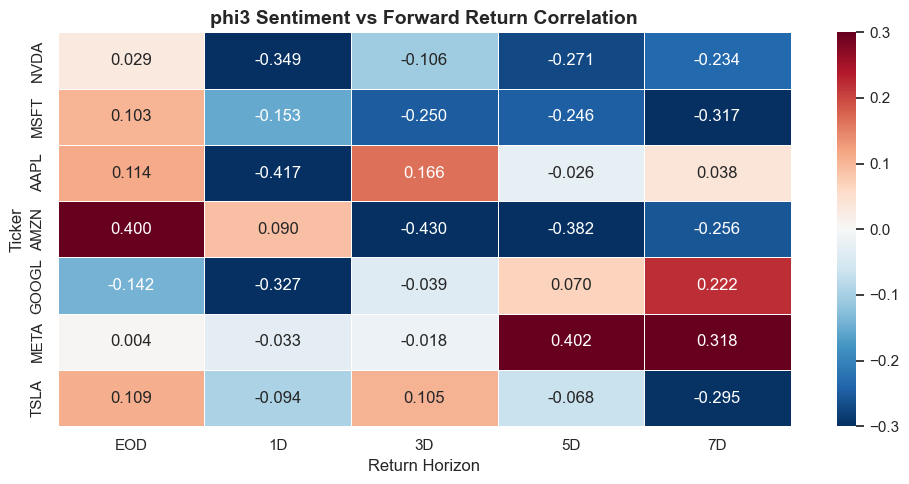

In [21]:
plot_sentiment_corr(aligned, sentiment_cols[1], "phi3 Sentiment vs Forward Return Correlation")

### llama3.2

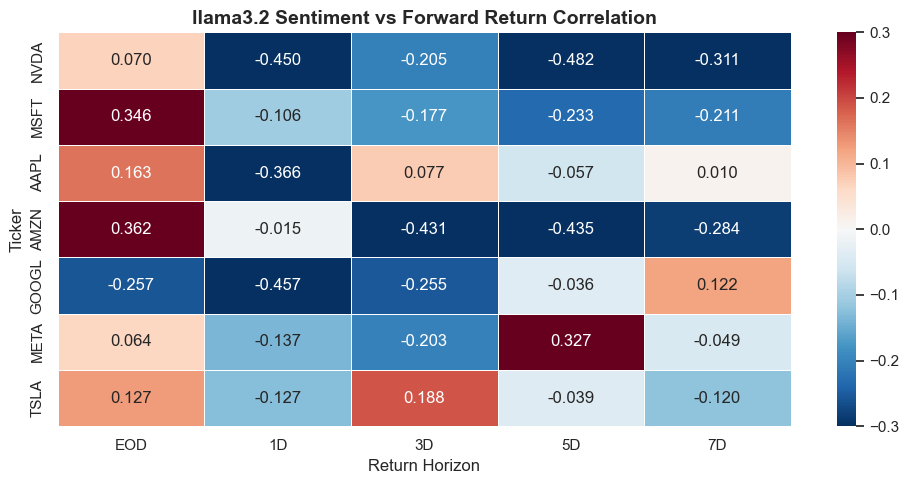

In [22]:
plot_sentiment_corr(aligned, sentiment_cols[2], "llama3.2 Sentiment vs Forward Return Correlation")

### deepseekr-1

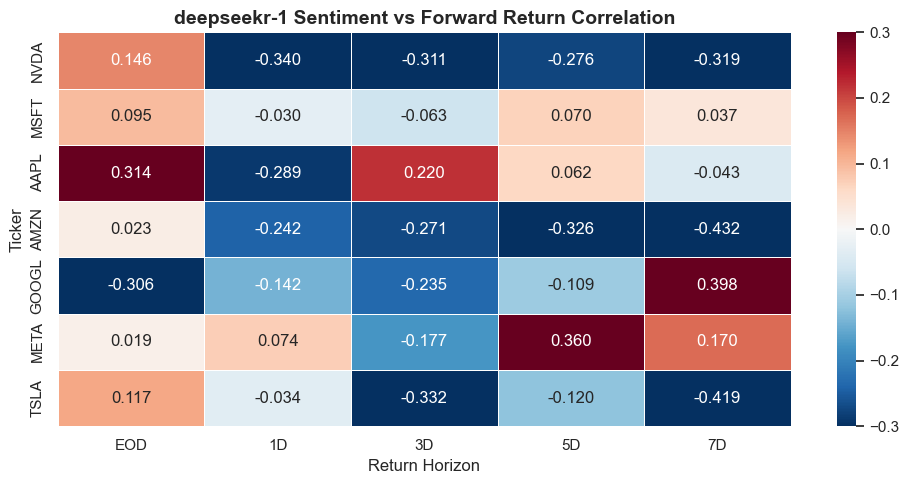

In [23]:
plot_sentiment_corr(aligned, sentiment_cols[3], "deepseekr-1 Sentiment vs Forward Return Correlation")

## Delta Analysis

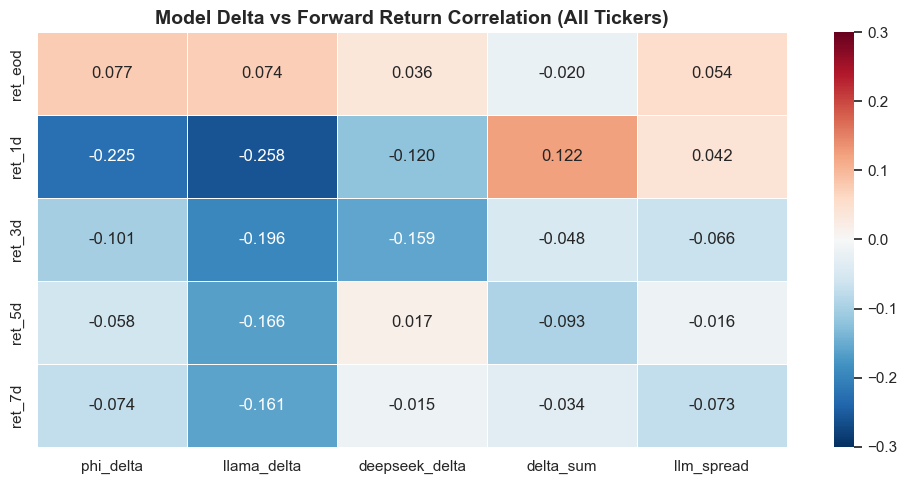

In [24]:
delta_cols = ["phi_delta", "llama_delta", "deepseek_delta", "delta_sum", "llm_spread"]

overall = aligned[delta_cols + horizon_cols].corr().loc[horizon_cols, delta_cols]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(overall, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax)
ax.set_title("Model Delta vs Forward Return Correlation (All Tickers)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Quintile Analysis

In [55]:
HORIZON_COLS = ["ret_eod", "ret_1d", "ret_3d", "ret_5d", "ret_7d"]
HORIZON_LABELS = {"ret_eod": "EOD", "ret_1d": "1D", "ret_3d": "3D", "ret_5d": "5D", "ret_7d": "7D"}
price_cols = ["ticker", "trade_date", "ret_eod", "ret_1d", "ret_3d", "ret_5d", "ret_7d"]
daily_q = daily.merge(
    prices[price_cols],
    left_on=["ticker", "date"],
    right_on=["ticker", "trade_date"],
    how="left"
)

daily_q["market_avg"] = daily_q.groupby("date")["ret_1d"].transform("mean")
for h in HORIZON_COLS:
    mkt = daily_q.groupby("date")[h].transform("mean")
    daily_q[f"excess_{h}"] = daily_q[h] - mkt
excess_cols = [f"excess_{h}" for h in HORIZON_COLS]


In [52]:
def plot_quintile_excess(daily_q, sentiment_col, excess_cols, horizon_labels, title=None):
    col_q = f"{sentiment_col}_q"
    daily_q[col_q] = pd.qcut(daily_q[sentiment_col], q=5, labels=["Q1","Q2","Q3","Q4","Q5"])
    
    quintile_means = daily_q.groupby(col_q, observed=True)[excess_cols].mean()
    quintile_means.columns = [horizon_labels[h.replace("excess_", "")] for h in excess_cols]
    
    plot_title = title or f"Mean Excess Forward Return by {sentiment_col} Quintile"
    
    ax = quintile_means.plot(kind="bar", figsize=(11, 5), colormap="tab10")
    ax.set_title(plot_title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Sentiment Quintile  (Q1 = Most Negative  →  Q5 = Most Positive)")
    ax.set_ylabel("Mean Excess Return")
    ax.axhline(0, color="black", linewidth=0.9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Horizon")
    plt.tight_layout()
    plt.show()

In [53]:
def plot_sentiment_change_quintile(daily_q, sentiment_col, excess_cols, horizon_labels, title=None):
    temp = daily_q.sort_values(["ticker", "date"]).copy()
    change_col = f"{sentiment_col}_change"
    temp[change_col] = temp.groupby("ticker")[sentiment_col].diff()

    temp = temp.dropna(subset=[change_col]).copy()
    temp["change_q"] = pd.qcut(temp[change_col], q=5, labels=["Q1","Q2","Q3","Q4","Q5"])

    qmeans = temp.groupby("change_q", observed=True)[excess_cols].mean()
    qmeans.columns = [horizon_labels[h.replace("excess_", "")] for h in excess_cols]

    plot_title = title or f"Mean Excess Forward Return by {sentiment_col} Change Quintile)"

    ax = qmeans.plot(kind="bar", figsize=(11, 5), colormap="tab10")
    ax.set_title(plot_title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Sentiment Change Quintile  (Q1 = Biggest Drop  →  Q5 = Biggest Rise)")
    ax.set_ylabel("Mean Excess Return")
    ax.axhline(0, color="black", linewidth=0.9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Horizon")
    plt.tight_layout()
    plt.show()

### FinBERT

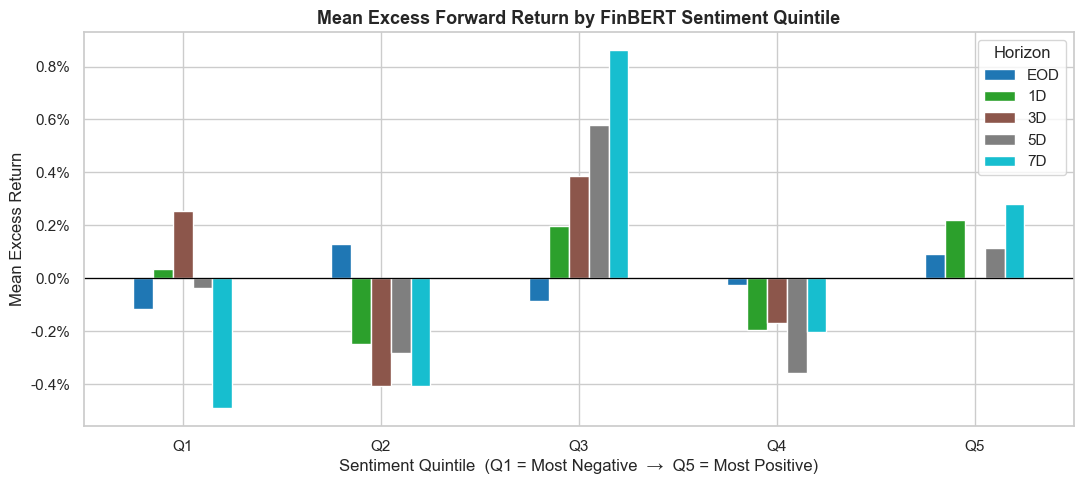

In [54]:
plot_quintile_excess(daily_q, "finbert_avg", excess_cols, HORIZON_LABELS,
                     title="Mean Excess Forward Return by FinBERT Sentiment Quintile")

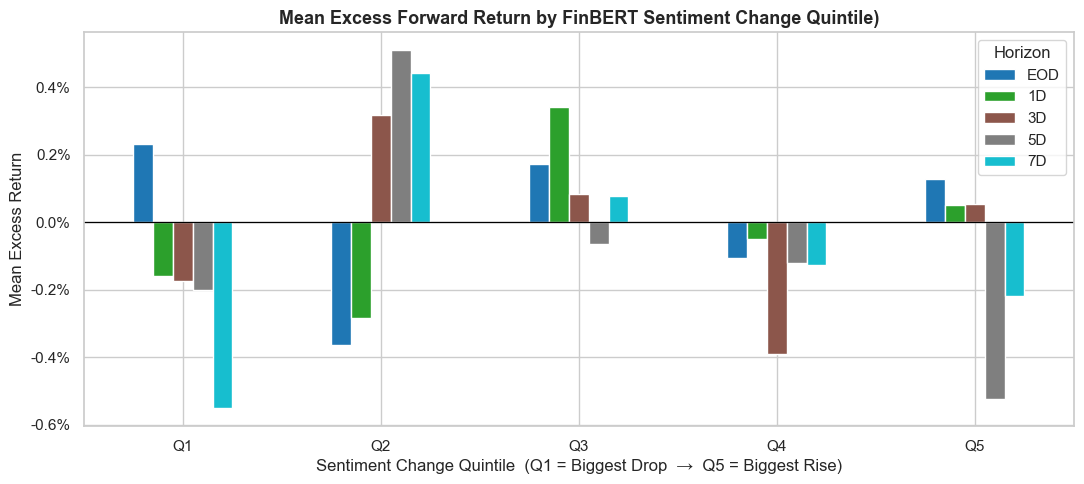

In [50]:
plot_sentiment_change_quintile(daily_q, "finbert_avg", excess_cols, HORIZON_LABELS,
    title="Mean Excess Forward Return by FinBERT Sentiment Change Quintile)")

### phi3

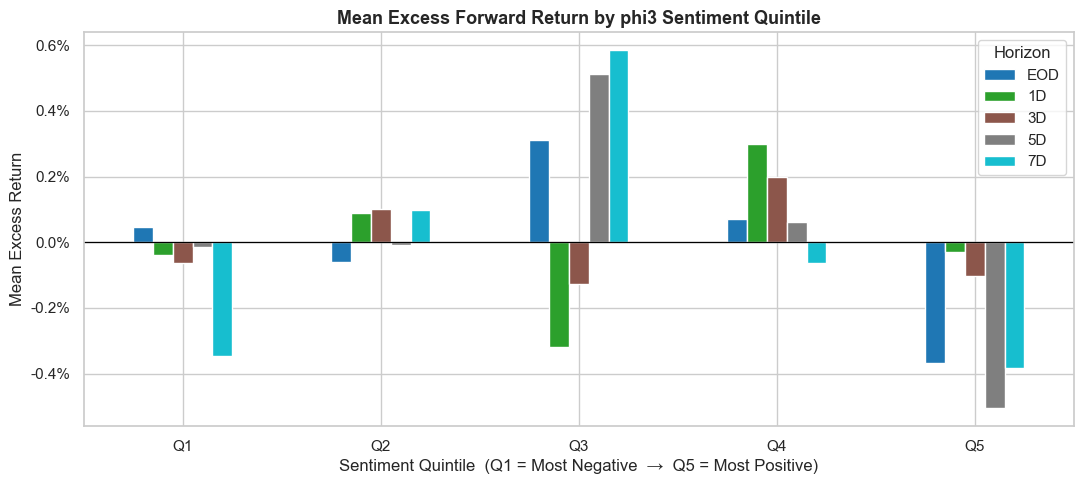

In [58]:
plot_quintile_excess(daily_q, "phi3_avg", excess_cols, HORIZON_LABELS,
                     title="Mean Excess Forward Return by phi3 Sentiment Quintile")


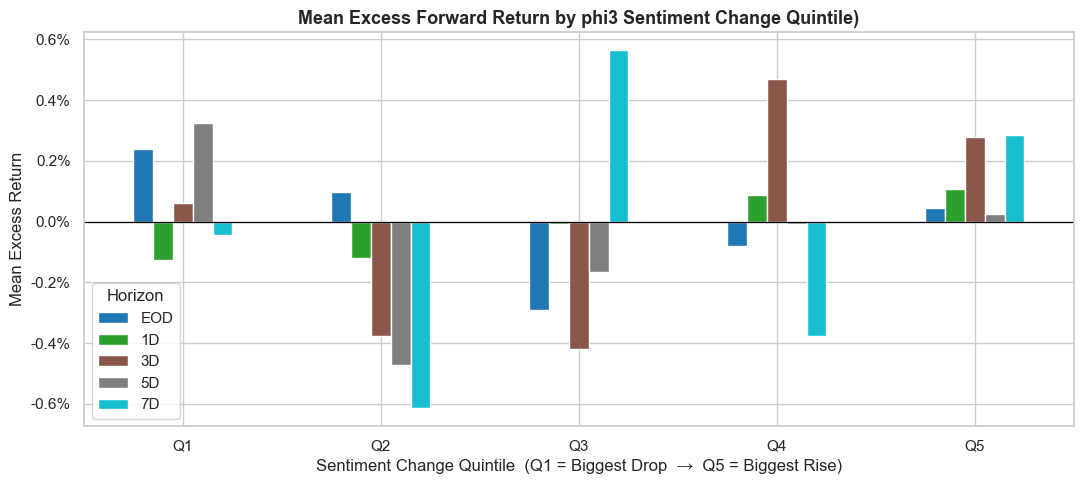

In [59]:
plot_sentiment_change_quintile(daily_q, "phi3_avg", excess_cols, HORIZON_LABELS,
    title="Mean Excess Forward Return by phi3 Sentiment Change Quintile)")

## llama3.2

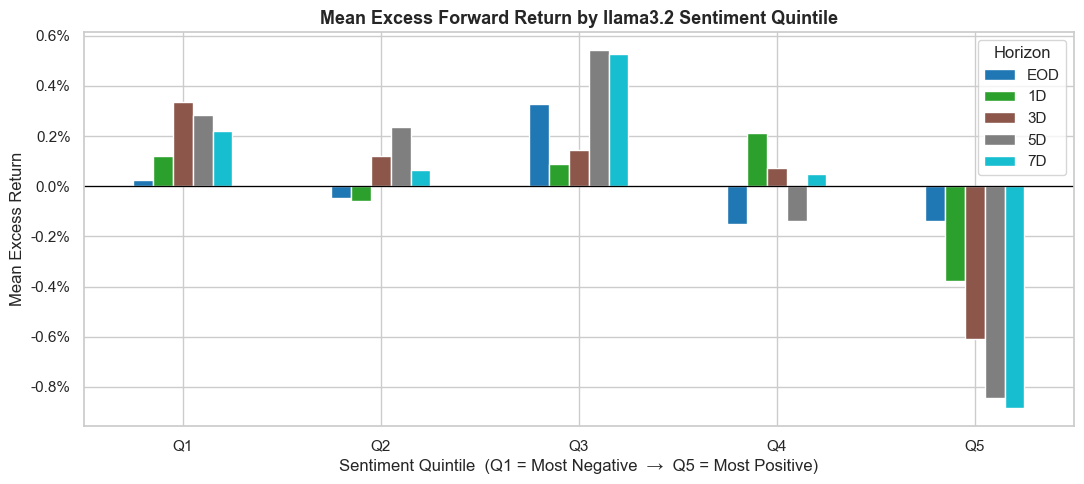

In [56]:
plot_quintile_excess(daily_q, "llama3_avg", excess_cols, HORIZON_LABELS,
                     title="Mean Excess Forward Return by llama3.2 Sentiment Quintile")

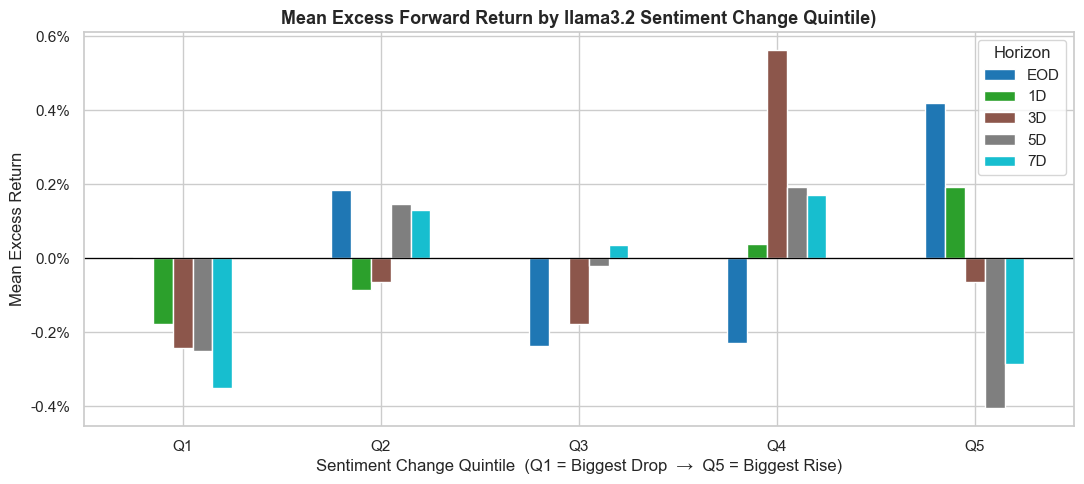

In [57]:
plot_sentiment_change_quintile(daily_q, "llama3_avg", excess_cols, HORIZON_LABELS,
    title="Mean Excess Forward Return by llama3.2 Sentiment Change Quintile)")

## deepseekr-1

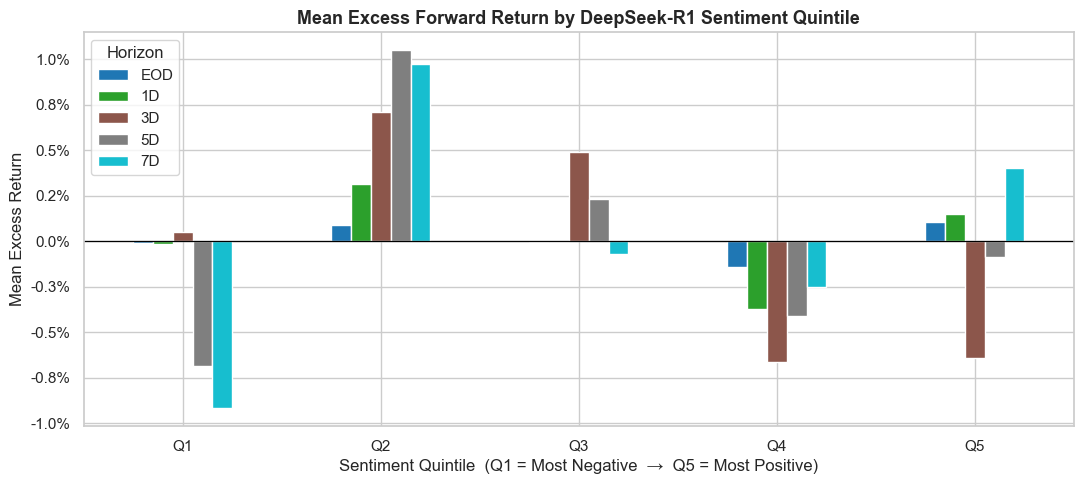

In [60]:
plot_quintile_excess(daily_q, "deepseek_avg", excess_cols, HORIZON_LABELS,
                     title="Mean Excess Forward Return by DeepSeek-R1 Sentiment Quintile")

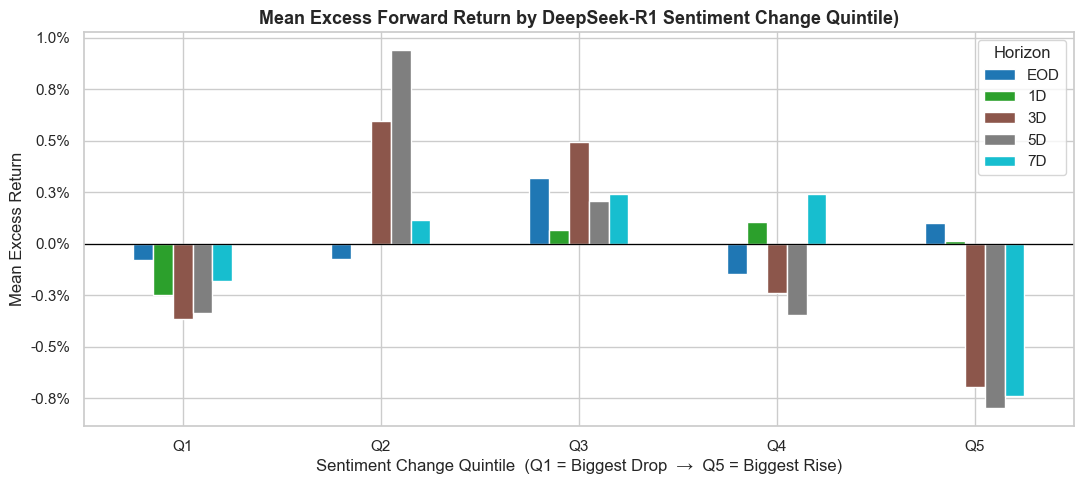

In [61]:
plot_sentiment_change_quintile(daily_q, "deepseek_avg", excess_cols, HORIZON_LABELS,
    title="Mean Excess Forward Return by DeepSeek-R1 Sentiment Change Quintile)")

## Hit Rates

In [29]:
# hit rate: did positive sentiment predict positive return?
for h in HORIZON_COLS:
    daily_q[f"hit_{h}"] = (
        (daily_q["finbert_avg"] > 0) & (daily_q[h] > 0) |
        (daily_q["finbert_avg"] < 0) & (daily_q[h] < 0)
    ).astype(int)

hit_cols = [f"hit_{h}" for h in HORIZON_COLS]
hit_rate = daily_q[hit_cols].mean()
hit_rate.index = [HORIZON_LABELS[h.replace("hit_", "")] for h in hit_cols]

print("Overall Hit Rate (FinBERT sentiment vs return direction):")
print(hit_rate.round(3))

Overall Hit Rate (FinBERT sentiment vs return direction):
EOD    0.375
1D     0.299
3D     0.299
5D     0.254
7D     0.232
dtype: float64


In [36]:
def plot_hit_rate(daily_q, sentiment_col, horizon_cols, horizon_labels, tickers=TICKERS, title=None):
    # build hit columns
    temp = daily_q.copy()
    hit_cols_local = []
    for h in horizon_cols:
        col = f"hit_{h}_{sentiment_col}"
        temp[col] = (
            ((temp[sentiment_col] > 0) & (temp[h] > 0)) |
            ((temp[sentiment_col] < 0) & (temp[h] < 0))
        ).astype(int)
        hit_cols_local.append(col)

    hit_rows = {}
    for t in tickers:
        sub = temp[temp["ticker"] == t]
        hit_rows[t] = sub[hit_cols_local].mean()

    hit_table = pd.DataFrame(hit_rows).T
    hit_table.columns = [horizon_labels[h.replace(f"hit_", "").replace(f"_{sentiment_col}", "")] for h in hit_cols_local]

    plot_title = title or f"{sentiment_col} Hit Rate by Ticker and Horizon\n(Green > 50% = directionally correct, Red < 50% = contrarian)"

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(
        hit_table,
        annot=True,
        fmt=".1%",
        cmap="RdYlGn",
        center=0.5,
        vmin=0.3,
        vmax=0.7,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(plot_title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Return Horizon")
    ax.set_ylabel("Ticker")
    plt.tight_layout()
    plt.show()

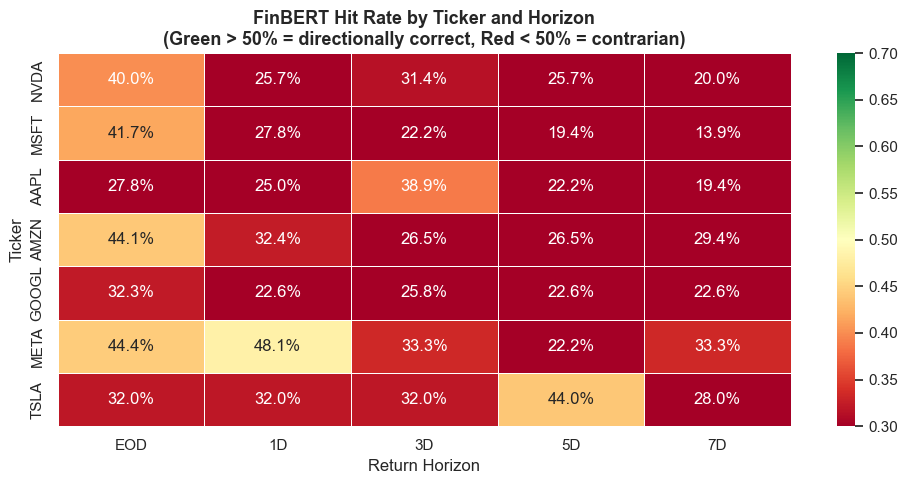

In [ ]:
plot_hit_rate(daily_q, "finbert_avg", HORIZON_COLS, HORIZON_LABELS,
              title="FinBERT Hit Rate by Ticker and Horizon\n(Green > 50% = directionally correct, Red < 50% = contrarian)")

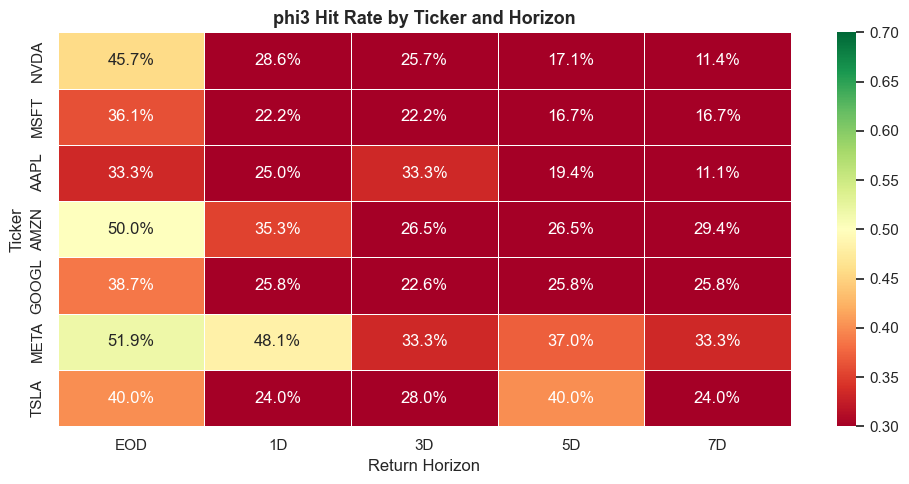

In [ ]:
plot_hit_rate(daily_q, "phi3_avg", HORIZON_COLS, HORIZON_LABELS,
              title="phi3 Hit Rate by Ticker and Horizon")

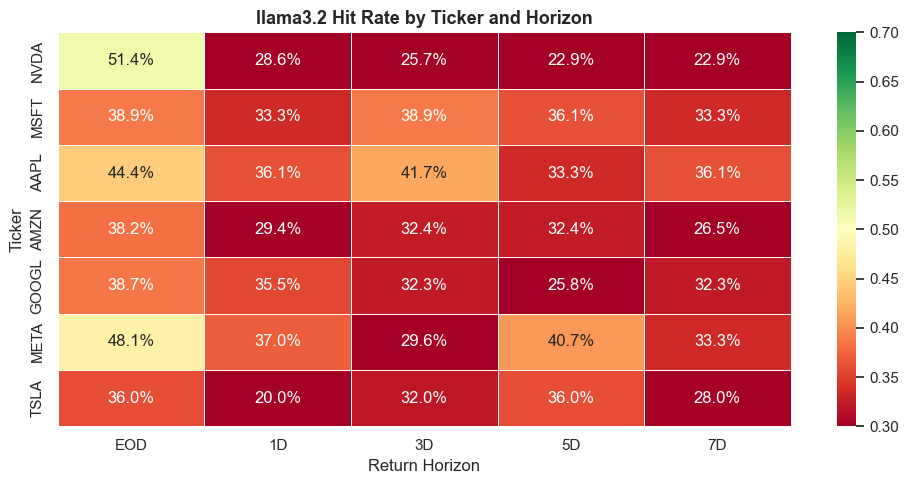

In [ ]:
plot_hit_rate(daily_q, "llama3_avg", HORIZON_COLS, HORIZON_LABELS,
              title="llama3.2 Hit Rate by Ticker and Horizon")

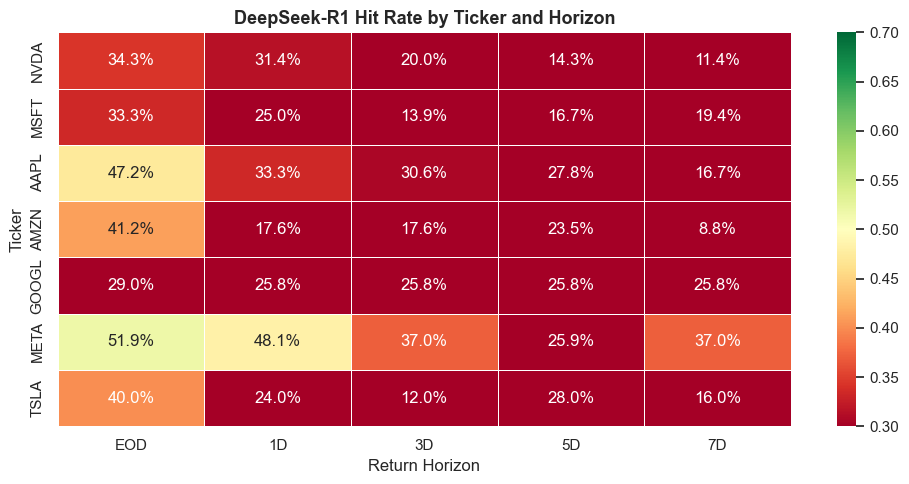

In [40]:
plot_hit_rate(daily_q, "deepseek_avg", HORIZON_COLS, HORIZON_LABELS,
              title="DeepSeek-R1 Hit Rate by Ticker and Horizon")


## Analysis Summary

### Correlation Analysis (Daily-Average Sentiment vs Forward Returns)
- **Short-horizon sentiment is broadly contrarian** — nearly every model shows negative 1D correlations for most tickers; positive headlines are consistently followed by next-day underperformance ("buy the rumor, sell the news")
- **AAPL is the clearest delayed-positive signal** — negative at 1D but strongly positive at 3D–7D across multiple models, suggesting slower sentiment-to-price transmission for this name
- **MSFT and AMZN show persistent negative drift** — broadly negative from 1D through 7D across models; positive sentiment on these names is not predictive at any medium horizon
- **META and GOOGL carry delayed positive signals at longer horizons** — phi3 and DeepSeek both show strong positives at 5D–7D for META; GOOGL flips positive by 7D in several models
- **TSLA is the most horizon-unstable ticker** — positive at EOD and 1D but sign flips by 7D; appears reactive to sentiment rather than predictable by it
- **llama3.2 produces the highest-magnitude correlations** — strongest signal amplitudes overall, particularly at 1D

> **"Buy the rumor, sell the news"** is a well-known market dynamic where traders position ahead of expected good news, pushing prices up before the headline drops. Once the positive news is published, early buyers sell into the attention — causing prices to decline even on good sentiment. This is the likely explanation for the persistent negative 1D correlations across all models and tickers: the signal is real, but in the opposite direction of what you'd naively expect. Treating high positive sentiment as a short-term bearish overlay is directionally consistent with this effect.

---

### Delta Analysis (LLM vs FinBERT Disagreement)
- **phi_delta and llama_delta are the most informative delta features** — both strongly negative at 1D (`−0.225`, `−0.258`); when LLMs rate a day more positively than FinBERT, next-day returns tend to underperform
- **llama_delta is the strongest single delta signal** — persistently negative from 1D through 7D; treating llama3.2 divergence from FinBERT as a contrarian overlay is a viable signal construction
- **delta_sum shows a positive 1D anomaly (+0.122)** — when all LLMs simultaneously diverge from FinBERT, next-day returns are weakly positive; collective disagreement may signal uncertainty that briefly resolves upward
- **llm_spread (cross-LLM disagreement) is near-neutral** — raw disagreement among LLMs does not predict returns; directional divergence from FinBERT matters more than LLM-to-LLM spread

---

### Quintile Analysis (Sentiment Level & Change vs Excess Returns)
- **Neutral sentiment (Q3) outperforms all other quintiles** — at 3D, 5D, and 7D, neutral-sentiment days produce the highest positive excess returns; sentiment extremes in either direction underperform
- **Q4 (mildly positive sentiment) is the weakest quintile** — consistent underperformance across horizons; "good but not great" sentiment appears already priced in
- **No monotonic Q1→Q5 pattern exists** — the sentiment-return relationship is non-linear; the market does not reward increasingly positive sentiment at any horizon tested
- **Sentiment change (momentum) is more informative than level** — Q2 (moderate decline in tone) is the strongest buy signal at 3D–7D, suggesting mild deterioration flags recoveries; Q4/Q5 (rising sentiment) are contrarian at medium horizons

---

### Hit Rate Analysis (Directional Accuracy)
- **All tickers and all horizons are below 50%** — FinBERT sentiment is a consistent contrarian indicator; positive sentiment days underperform directionally more often than not at every horizon
- **Hit rates worsen at longer horizons** — e.g., MSFT drops from ~42% at EOD to ~14% at 7D; the contrarian effect compounds as the horizon extends
- **AMZN and META are the least contrarian** — hit rates closest to 50% at EOD; more noise in the sentiment-return relationship for these names
- **The signal is most useful when inverted** — treating high FinBERT daily average as a bearish overlay is consistent across all four analyses

---

### Overall Conclusion
- **Sentiment is primarily a contrarian indicator** at short-to-medium horizons for Mag-7 headlines in this dataset; high positive sentiment tends to precede underperformance
- **Ticker specificity matters** — AAPL and META carry the clearest delayed positive signals; NVDA, MSFT, and AMZN are the most persistently contrarian
- **FinBERT as a grounding baseline adds value** — LLM delta vs FinBERT is more informative than raw LLM scores or cross-LLM spread; FinBERT anchors genuine financial tone
- **Sample size caveat** — all findings are based on ~35 days of data; treat patterns as directional hypotheses until 3–6 months of consistent collection are available

## Next Steps - Larger Model Comparisons
- Current LLMs are in the 1.5B–3B range, which limits their ability to understand financial nuance, sarcasm, and context in headlines
- `qwen2.5:7b`, `llama3.1:8b`, and `mistral:7b` should produce more contextually accurate sentiment scores at a comparable local compute cost

**Testing the following questions:**
- Does model quality actually improve the sentiment-return correlation?
- Do bigger models agree more or less with each other vs the smaller ones?
- Does the "buy the rumor, sell the news" pattern hold or weaken with better scoring?